In [14]:
import pandas as pd
import numpy as np

data={
    'user_id' : [101, 102, 103, 104, 105, 106, 107, 108],
    'tanggal_akses' : pd.date_range(start='2024-05-01', periods=8),
    'durasi_menit' : [45, 10, 120, 5, 60, 30, 150 ,20],
    'fitur_utama' : ['Video', 'Kuis', 'Video', 'Forum', 'Kuis', 'Video', 'Video', 'Kuis'],
    'skor_kepuasan' : [5, 4, np.nan, 2, np.nan, 5, 4, np.nan]
}

df = pd.DataFrame(data)
print("--- Data Aktivitas Pengguna Berhasil Dimuat ---")
print(df)


--- Data Aktivitas Pengguna Berhasil Dimuat ---
   user_id tanggal_akses  durasi_menit fitur_utama  skor_kepuasan
0      101    2024-05-01            45       Video            5.0
1      102    2024-05-02            10        Kuis            4.0
2      103    2024-05-03           120       Video            NaN
3      104    2024-05-04             5       Forum            2.0
4      105    2024-05-05            60        Kuis            NaN
5      106    2024-05-06            30       Video            5.0
6      107    2024-05-07           150       Video            4.0
7      108    2024-05-08            20        Kuis            NaN


In [11]:
rata_rating = df['skor_kepuasan'].mean()
data_kosong = df['skor_kepuasan'].isna().sum()
mean_durasi = df['durasi_menit'].mean()
median_durasi = df['durasi_menit'].median()
min_durasi = df['durasi_menit'].min()
max_durasi = df['durasi_menit'].max()


print(f"--- Laporan Analisis Awal ---")
print(f"Rata-rata Rating (dari yang mengisi): {rata_rating:.1f} / 5.0")
print(f"Jumlah User belum mengisi rating: {data_kosong} user")
print(f"-----------------------------")
print(f"Rata-rata Durasi Belajar (Mean): {mean_durasi} menit")
print(f"Nilai Tengah Durasi (Median): {median_durasi} menit")
print(f"Rentang Waktu: {min_durasi} menit hingga {max_durasi} menit")



--- Laporan Analisis Awal ---
Rata-rata Rating (dari yang mengisi): 4.0 / 5.0
Jumlah User belum mengisi rating: 3 user
-----------------------------
Rata-rata Durasi Belajar (Mean): 55.0 menit
Nilai Tengah Durasi (Median): 37.5 menit
Rentang Waktu: 5 menit hingga 150 menit


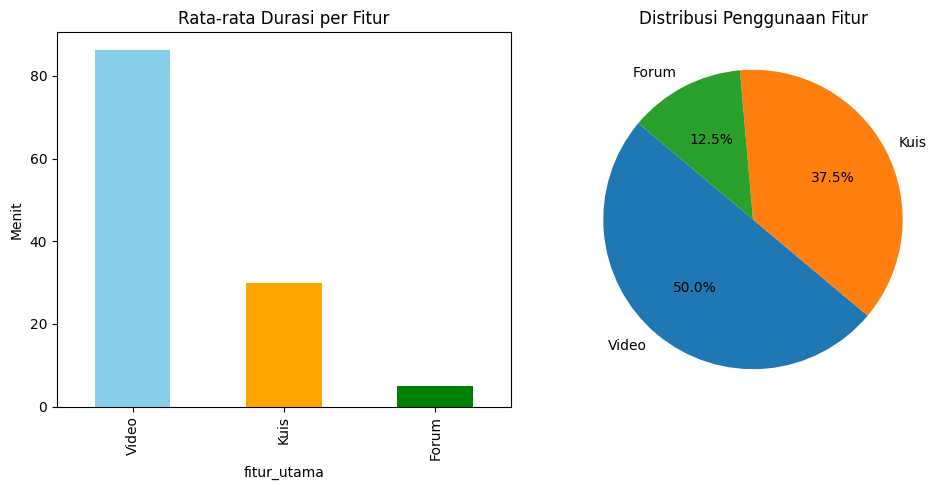

In [15]:
import matplotlib.pyplot as plt

# Menghitung rata-rata durasi per fitur
rerata_per_fitur = df.groupby('fitur_utama')['durasi_menit'].mean().sort_values(ascending=False)

# Menghitung jumlah pengguna per fitur (Modus)
jumlah_user_per_fitur = df['fitur_utama'].value_range().count() if hasattr(df['fitur_utama'], 'value_range') else df['fitur_utama'].value_counts()

# Membuat Grafik
plt.figure(figsize=(10, 5))

# Subplot 1: Durasi per Fitur
plt.subplot(1, 2, 1)
rerata_per_fitur.plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.title('Rata-rata Durasi per Fitur')
plt.ylabel('Menit')

#  Popularitas Fitur (Modus)
plt.subplot(1, 2, 2)
jumlah_user_per_fitur.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Distribusi Penggunaan Fitur')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
nama_file_csv = "data_hasil_analisis_gtech.csv"

df.to_csv(nama_file_csv, index=False)

print(f"Sukses! Data telah disimpan dalam file: {nama_file_csv}")

✅ Sukses! Data telah disimpan dalam file: data_hasil_analisis_gtech.csv


In [ ]:
nama_file_excel = "data_hasil_analisis_gtech.xlsx"
df.to_excel(nama_file_excel, index=False)

print(f"Data berhasil dikonversi ke Excel: {nama_file_excel}")

1. Masalah Bisnis (Business Problem)
Tujuan analisis ini adalah memahami pola keaktifan pengguna dan mencari tahu mengapa ada indikasi penurunan aktivitas (drop-off), serta menentukan fitur mana yang paling efektif dalam menahan pengguna di aplikasi.

2. Temuan Utama (Key Insights)
Keaktifan Pengguna: Rata-rata durasi belajar adalah 55 menit, namun angka ini terdistorsi oleh pengguna ekstrem. Angka yang lebih mewakili mayoritas pengguna adalah 37,5 menit (Median).


Dominasi Fitur: Fitur Video adalah fitur yang paling banyak digunakan (50% dari total akses) dan menghasilkan durasi belajar terlama.


Isu Data: Ditemukan 3 user yang tidak mengisi skor kepuasan, yang menunjukkan perlunya evaluasi pada sistem pengumpulan feedback agar lebih proaktif.

3. Rekomendasi Strategis (Action Plan)
Berdasarkan analisis data dan logika bisnis:

Integrasi Alur Belajar: Menambahkan sesi otomatis Forum atau Kuis singkat (5-10 menit) segera setelah sebuah video selesai ditonton. Ini bertujuan meningkatkan kesadaran fitur dan memperdalam pemahaman materi.

Optimalisasi Forum: Daripada menghapus fitur yang berdurasi pendek, Forum harus dikembangkan dengan konten yang lebih interaktif untuk melihat apakah retensi meningkat di masa depan.


Monitoring Berkelanjutan: Melakukan evaluasi mendalam jika tren penggunaan Forum/Kuis terus menurun dalam 1-3 bulan ke depan untuk memutuskan efisiensi fitur tersebut.